In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
#Importing libraries
import numpy as np
import random
import matplotlib.pyplot as plt

np.random.seed(0)


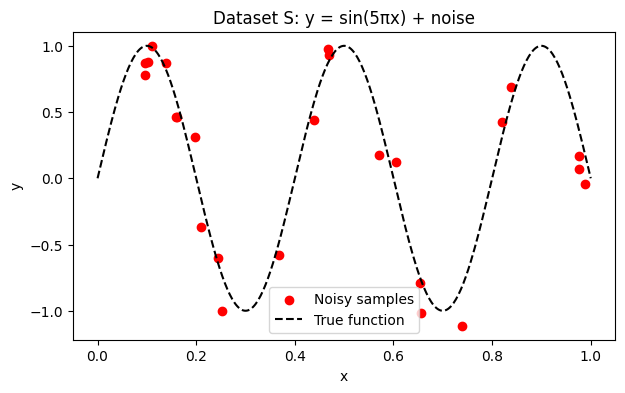

In [7]:
n = 25
x = np.random.rand(n) # Random x values in from 0 to 1
noise = np.random.uniform(-0.3, 0.3, size=n)

y = np.sin(5 * np.pi * x) + noise #y = sin(5πx) + noise


idx = np.argsort(x) # This function is only to sort the data
x, y = x[idx], y[idx]


plt.figure(figsize=(7,4))
plt.scatter(x, y, color='red', label='Noisy samples')

x_true = np.linspace(0, 1, 400)
y_true = np.sin(5 * np.pi * x_true)

plt.plot(x_true, y_true, 'k--', label='True function')
plt.title("Dataset S: y = sin(5πx) + noise")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


In [8]:
def poly_features(x, degree=10): # This Function will generate polynomial equations to N degree
    return np.vander(x, N=degree+1, increasing=True)

def ridge_fit(X, y, lam): # w = (X^T X + λI)^(-1) X^T y
    XtX = X.T @ X # np.dot(T, X)
    reg = lam * np.eye(X.shape[1])
    reg[0,0] = 0  # do NOT penalize the bias
    w = np.linalg.solve(XtX + reg, X.T @ y)
    return w

def predict(X, w):
    return X @ w

def mse(a, b):
    return np.mean((a - b)**2)


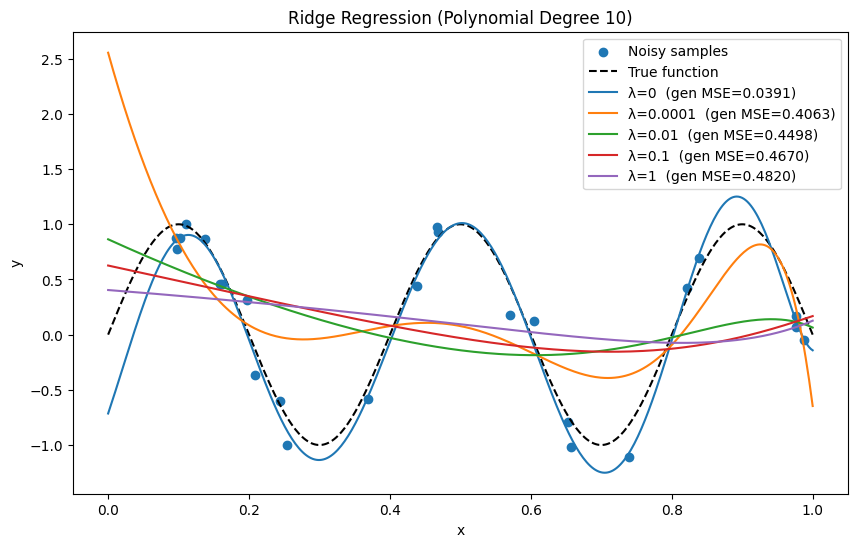

[{'lambda': 0,
  'weights': array([-7.14612996e-01,  1.92084894e+01,  4.08764917e+01, -2.35006891e+02,
         -1.17358708e+04,  9.04493991e+04, -2.81443067e+05,  4.59568284e+05,
         -4.14921029e+05,  1.96232191e+05, -3.79744123e+04]),
  'train_mse': 0.016042902184629476,
  'generalization_mse': 0.03911292114041474},
 {'lambda': 0.0001,
  'weights': array([  2.55468085, -22.84573576,  59.91660268, -27.3015021 ,
         -47.99246504, -13.49865632,  25.53214991,  42.24938415,
          31.45931989,  -1.66143279, -49.05917551]),
  'train_mse': 0.22403728684163696,
  'generalization_mse': 0.40625805268207854},
 {'lambda': 0.01,
  'weights': array([ 0.86410639, -2.90154905,  1.39319627,  0.5773644 ,  0.06145254,
          0.26622045,  0.56778016,  0.59001826,  0.25050608, -0.38726699,
         -1.21764527]),
  'train_mse': 0.36461622304342683,
  'generalization_mse': 0.44984753129105814},
 {'lambda': 0.1,
  'weights': array([ 0.62625505, -1.38261397, -0.11596505,  0.23108923,  0.3038

In [9]:
degree = 10
X = poly_features(x, degree)
X_true_grid = poly_features(x_true, degree)

lambdas = [0, 1e-4, 1e-2, 1e-1, 1] # Testing lamda values
ridge_results = []

plt.figure(figsize=(10,6))

# Plot original data + true curve first
plt.scatter(x, y, label='Noisy samples')
plt.plot(x_true, y_true, 'k--', label='True function')


for lam in lambdas:
    w = ridge_fit(X, y, lam) # Fit model
    y_pred = predict(X_true_grid, w)
    train_mse = mse(predict(X, w), y)
    gen_mse = mse(y_pred, y_true)

    ridge_results.append({
        "lambda": lam,
        "weights": w,
        "train_mse": train_mse,
        "generalization_mse": gen_mse
    })

    # Plot prediction curve
    plt.plot(x_true, y_pred, label=f"λ={lam}  (gen MSE={gen_mse:.4f})")

plt.title("Ridge Regression (Polynomial Degree 10)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

ridge_results


In [10]:
def rbf_design_matrix(x, centers, sigma):# rbf feature
    x = np.asarray(x)[:, None]     
    centers = np.asarray(centers)[None, :] 

    # Compute squared distances between x and each center
    Phi = np.exp(-(x - centers)**2 / (2 * sigma**2))

    # Add bias column
    return np.hstack([np.ones((len(x),1)), Phi])


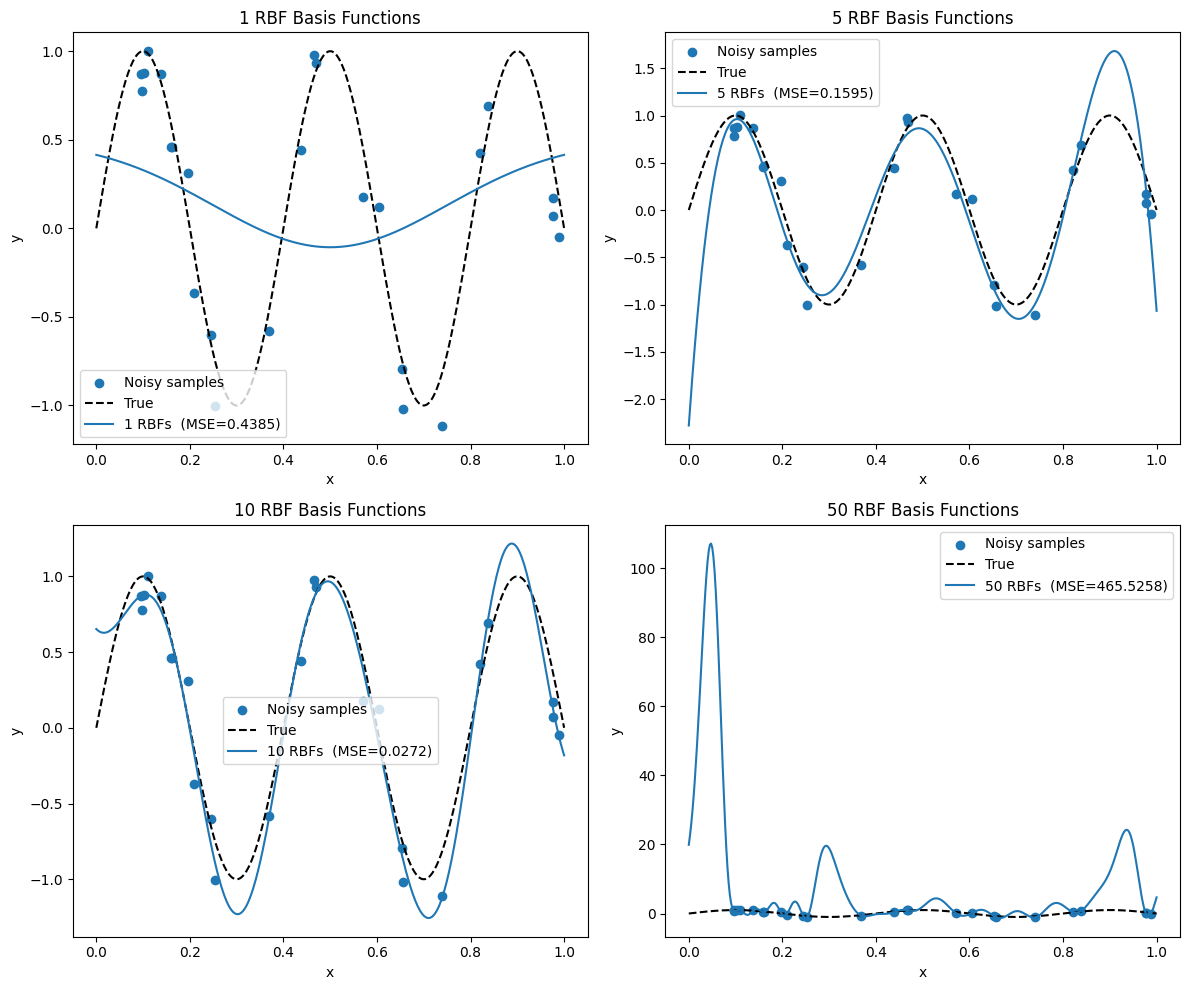

[{'k': 1,
  'centers': [0.5],
  'sigma': 0.25,
  'weights': array([ 0.49637641, -0.60308665]),
  'generalization_mse': 0.4384791583741924},
 {'k': 5,
  'centers': array([0.  , 0.25, 0.5 , 0.75, 1.  ]),
  'sigma': 0.25,
  'weights': array([-98.34315625,  89.89740899,  -8.98661008,  86.48067234,
         -10.65008529,  92.10191164]),
  'generalization_mse': 0.15950885481732002},
 {'k': 10,
  'centers': array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
         0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
  'sigma': 0.1111111111111111,
  'weights': array([ 4.47389336, -3.84387841,  0.57279994, -2.0295636 , -4.55422941,
          0.8881804 , -2.43227927, -1.01790798, -5.902329  ,  4.45986818,
         -6.54952392]),
  'generalization_mse': 0.027220749340801986},
 {'k': 50,
  'centers': array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
         0.10204082, 0.12244898, 0.14285714, 0.16326531, 0.18367347,
         0.20408163, 0.2244898 , 0.24

In [11]:
rbf_list = [1, 5, 10, 50]   
rbf_results = []

plt.figure(figsize=(12,10))

for i, k in enumerate(rbf_list, 1):
    if k == 1:
        centers = [0.5]     
        sigma = 0.25      
    else:
        centers = np.linspace(0, 1, k)   
        sigma = centers[1] - centers[0]  # distance between centers

    Phi = rbf_design_matrix(x, centers, sigma)


    w_rbf, *_ = np.linalg.lstsq(Phi, y, rcond=None)


    Phi_true = rbf_design_matrix(x_true, centers, sigma)
    y_pred = Phi_true @ w_rbf

    gen_mse = mse(y_pred, y_true)

    rbf_results.append({
        "k": k,
        "centers": centers,
        "sigma": sigma,
        "weights": w_rbf,
        "generalization_mse": gen_mse
    })

    plt.subplot(2,2,i)
    plt.scatter(x, y, label="Noisy samples")
    plt.plot(x_true, y_true, 'k--', label="True")
    plt.plot(x_true, y_pred, label=f"{k} RBFs  (MSE={gen_mse:.4f})")
    plt.title(f"{k} RBF Basis Functions")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()

plt.tight_layout()
plt.show()

# Show numeric results
rbf_results
